### Production NASNetLarge CNN Training Using SAM-Processed Chum Salmon Scale Images

This script trains the production NASNetLarge convolutional neural network using SAM-preprocessed chum salmon scale images from AFSC, ADF&G, DFO, and NSRAA.

The SAM-processed images were randomly divided into training (70%), validation (15%), and test (15%) datasets, stratified by total age to maintain a similar age-class distribution across each dataset. Each dataset was stored in a separate directory on disk.

The script loads and standardizes the images and trains the model using a two-phase transfer-learning strategy. The final trained model, including its architecture and learned weights, is saved to disk for subsequent evaluation and inference.

Date: 09/09/2025

In [1]:
#loading packages

from PIL import Image
import numpy as np
import pandas as pd
import tensorrt
import io
#import cx_Oracle 
import numpy.random as nr
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
#import keras.utils.np_utils as ku
import keras.layers as layers
from keras import optimizers
import time

%matplotlib inline

2025-09-09 15:42:06.014449: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
start = time.time()

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    print(e)

2 Physical GPUs, 2 Logical GPUs


2025-09-09 15:42:07.312277: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-09 15:42:07.312418: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-09 15:42:07.318092: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

### Counting images in folder

In [4]:
# counting the total number of images within the folder
import glob
import random
import os, shutil

import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    files = os.listdir(folder_path)
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    image_files = [f for f in files if f.lower().endswith(image_extensions)]
    
    num_images = len(image_files)

    return num_images

folder_training_path = '/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training' 
folder_validation_path = '/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Validation'

num_images = count_images_in_folder(folder_training_path)
print(f'Number of images in {folder_training_path}: {num_images}')

Number of images in /opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training: 11012


### Counting images in folder by age class

In [5]:
import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    files = os.listdir(folder_path)

    counts = {
        '_1': 0, '_2': 0, '_3': 0, '_4': 0,
        '_5': 0, '_6': 0, '_7': 0
    }
    
    for file in files:
        if file.lower().endswith(image_extensions):
            base_name = os.path.splitext(file)[0].lower()
            
            for suffix in counts.keys():
                if base_name.endswith(suffix):
                    counts[suffix] += 1
                    break

    return counts

counts = count_images_in_folder(folder_training_path)
print(f"Counts of images in {folder_training_path}:")
for suffix, count in counts.items():
    print(f"{suffix}: {count}")

Counts of images in /opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training:
_1: 123
_2: 76
_3: 2767
_4: 4265
_5: 3602
_6: 172
_7: 7


In [6]:
# loop through image in memory and extracts the age class label from the end of the file name 
# and create a pandas dataframe that includes the filename and label (total age).

import os

def load_images_from_folder(folder_path):
    labels = ['_1', '_2', '_3', '_4', '_5', '_6', '_7']
    files_by_label = {label: [] for label in labels}
    
    for file in os.listdir(folder_path):
        for label in labels:
            if file.lower().endswith(label + '.png') or \
               file.lower().endswith(label + '.jpg') or \
               file.lower().endswith(label + '.jpeg') or \
               file.lower().endswith(label + '.tif') or \
               file.lower().endswith(label + '.tiff'):
                files_by_label[label].append(file)  # <-- fixed here
    
    data = [(file, label) for label, files in files_by_label.items() for file in files]
    
    return pd.DataFrame(data, columns=['filename', 'label'])

# Load images from both the training and validation folders
df_train = load_images_from_folder(folder_training_path)
df_val = load_images_from_folder(folder_validation_path)

# Print samples of the data
print("Training set sample:")
print(df_train.head())
print(f"Total images in training set: {len(df_train)}")

print("\nValidation set sample:")
print(df_val.head())
print(f"Total images in validation set: {len(df_val)}")


Training set sample:
                  filename label
0   Chum_SCL_2004_92_1.tif    _1
1  Chum_SCL_2002_144_1.tif    _1
2   Chum_SCL_2007_16_1.tif    _1
3   Chum_SCL_2004_95_1.tif    _1
4  Chum_SCL_2002_129_1.tif    _1
Total images in training set: 11012

Validation set sample:
                  filename label
0   Chum_SCL_2006_07_1.tif    _1
1  Chum_SCL_2002_115_1.tif    _1
2  Chum_SCL_2002_125_1.tif    _1
3   Chum_SCL_2011_01_1.tif    _1
4  Chum_SCL_2002_148_1.tif    _1
Total images in validation set: 2365


In [7]:
# this simply removes the underscore that was used to separate file name from the age value

df_val['label'] = df_val['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_val['label'] = pd.to_numeric(df_val['label'], errors='coerce')

df_train['label'] = df_train['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_train['label'] = pd.to_numeric(df_train['label'], errors='coerce')

df_train.head()

,filename,label
0,Chum_SCL_2004_92_1.tif,1
1,Chum_SCL_2002_144_1.tif,1
2,Chum_SCL_2007_16_1.tif,1
3,Chum_SCL_2004_95_1.tif,1
4,Chum_SCL_2002_129_1.tif,1


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11012 entries, 0 to 11011
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  11012 non-null  object
 1   label     11012 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 172.2+ KB


In [9]:
# separating the file name and age label into two separate lists but they maintain the same index
val_images_link = df_val['filename'].tolist()
val_labels = df_val['label'].tolist()

train_images_link = df_train['filename'].tolist()
train_labels = df_train['label'].tolist()

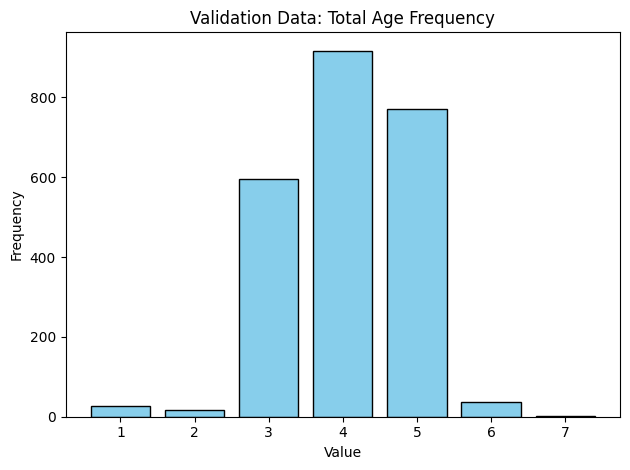

In [10]:
# show distribution by age class
from collections import Counter

count_data = Counter(val_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Validation Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('ValidationAgeLabels.pdf') 
plt.show()

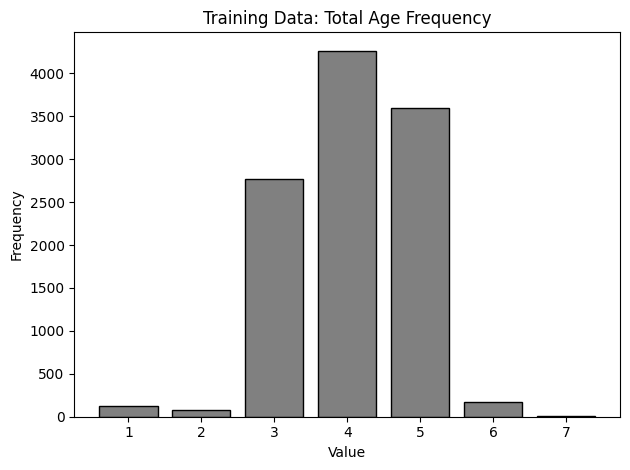

In [11]:
# show distribution by age class
count_data = Counter(train_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='gray', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Training Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('TrainingAgeLabels.pdf') 
plt.show()

In [12]:
# This is a key cell block, it links the file name from the image list
# Those images are resized and then into a dict. 
# The index is maintained from the test_images_link in order to link them back to the age labels 
# This step is very efficient if the computer has sufficient memory otherwise batch processing would be necessary.

train_images = {}
val_images = {}
def load_images(image_filenames, folder_path):

    images = {}
    target_size = (512, 512)
    
    for filename in image_filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.exists(file_path):
            with Image.open(file_path) as img:
                resized_img = img.resize(target_size, Image.LANCZOS)
                images[filename] = resized_img.copy()
        else:
            print(f"File {filename} not found in {folder_path}")
    
    return images

train_images = load_images(train_images_link, folder_training_path)
val_images = load_images(val_images_link, folder_validation_path)

In [13]:
# This block creates two functions to make sure all images have 3-channe, ie are color images, and if not to covert them regardless of the image imput type. 
# Important: The Keras models used in this project require all input images to be in color, have 3-channels
import cv2
from tqdm import tqdm

def process_image(img):

    if not isinstance(img, Image.Image):
        raise TypeError("Input has to be a PIL.Image.Image object.")
    
    img_np = np.array(img)
    
    print(f"Processing image with shape: {img_np.shape}")
    
    if len(img_np.shape) == 2:
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif len(img_np.shape) == 3:
        if img_np.shape[2] == 1:
            img_rgb = np.repeat(img_np, 3, axis=2)
        elif img_np.shape[2] == 3:
            img_rgb = img_np
        else:
            raise ValueError(f"Unexpected number of channels in the image: {img_np.shape[2]}")
    else:
        raise ValueError(f"Unexpected image dimensions: {img_np.shape}")
    
    return img_rgb

def process_images(image_dict):
    processed_images = []
    error_count = 0
    for filename, img in tqdm(image_dict.items(), desc="Processing Images"):
        try:
            processed_img = process_image(img)
            processed_images.append(processed_img)
        except (TypeError, ValueError) as e:
            print(f"Error processing {filename}: {e}")
            error_count += 1
    
    print(f"Number of errors: {error_count}")
    return processed_images


In [14]:
# This code running the above functions, creating the images to array and normalizing them. 
processed_train_images = process_images(train_images)
processed_train_images = np.array(processed_train_images)
x_train = processed_train_images.astype("float32") / 255

processed_val_images = process_images(val_images) 
processed_val_images = np.array(processed_val_images)
x_val = processed_val_images.astype("float32") / 255


for img in val_images.values():
    img.close()
for img in train_images.values():
    img.close()

Processing Images:   3%|█▊                                                        | 341/11012 [00:00<00:06, 1707.51it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:   6%|███▋                                                      | 697/11012 [00:00<00:05, 1750.57it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:   8%|████▋                                                     | 888/11012 [00:00<00:05, 1805.73it/s]

...

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:  96%|███████████████████████████████████████████████████████▋  | 2271/2365 [00:01<00:00, 1926.02it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images: 100%|██████████████████████████████████████████████████████████| 2365/2365 [00:01<00:00, 1887.73it/s]


Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

In [15]:
# Count of images in memory
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_val.shape[0], "val samples")

x_train shape: (11012, 512, 512, 3)
11012 train samples
2365 val samples


In [16]:
# subtracting 1 from the labels. We don't have an zero total ages
y_val_class = np.asarray([float(num) - 1 for num in val_labels])
y_train_class = np.asarray([float(num) - 1 for num in train_labels])

In [17]:
import gc

del train_images, val_images, df_train, df_val, processed_train_images, processed_val_images
gc.collect()

0

In [18]:
tf.keras.backend.clear_session()

In [19]:
# Checking available GPUs 
print("GPU available: ", tf.config.list_physical_devices('GPU'))

GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [20]:
import tensorflow as tf
#from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

#Create a MirroredStrategy for multi-GPU usage
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Optional: Function to add noise (if needed)
def add_noise(image):
    noise_factor = 0.05  # Adjust noise level
    noise = np.random.normal(0, noise_factor, image.shape)
    image_noisy = image + noise
    return np.clip(image_noisy, 0., 255.)

datagen = ImageDataGenerator(
    rotation_range=360,
    vertical_flip=True,
    horizontal_flip=True,  
    shear_range=0.15,  
    zoom_range=[0.97, 1.02],
    height_shift_range=0.04,  
    width_shift_range=0.04,
    fill_mode='constant',
    cval=0,
#    preprocessing_function=add_noise  # Optional: Add Gaussian noise to the image
)

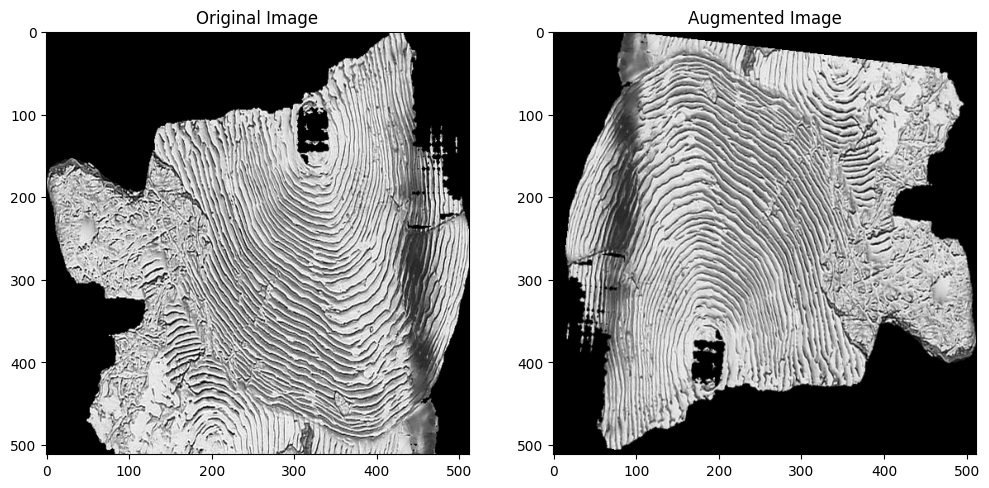

In [22]:
index_to_visualize = 33
image_to_visualize = x_train[index_to_visualize]

image_to_visualize = np.expand_dims(image_to_visualize, axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(1, 2, 1)
plt.imshow(image_to_visualize[0])
plt.title('Original Image')

augmented_image = datagen.flow(image_to_visualize).next()[0]

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title('Augmented Image')

#plt.savefig('ExampleAugmentedImageProcess.pdf')
plt.show()

In [23]:
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam  #  legacy version to avoid KeyError
#from tensorflow.keras.optimizers.legacy import SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

strategy = tf.distribute.MirroredStrategy()

input_shape = (512, 512, 3)
batch_size = 16
learning_rate = 1e-4
max_epochs = 150
initial_epochs = 50
patience = 9

NASNetLarge_train_generator = datagen.flow(x_train, y_train_class, batch_size=batch_size)

with strategy.scope():
    pretrained_NASNetLarge = NASNetLarge(
        weights='imagenet', 
        include_top=False, 
        pooling=None,  
        input_shape=input_shape)

    # Freeze the first one-third of the layers
    num_layers = len(pretrained_NASNetLarge.layers)
    one_third_index = num_layers // 3
    for layer in pretrained_NASNetLarge.layers[:one_third_index]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(pretrained_NASNetLarge.output)
    x = Dense(4096, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='linear')(x)

    NASNetLargemodel = Model(inputs=pretrained_NASNetLarge.input, outputs=predictions)

    # Compile the model within the strategy scope
    optimizer = Adam(learning_rate=learning_rate)
    NASNetLargemodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse'])

NASNetLargefilepath = 'NASNetLarge_SAM_model_992025_file.hdf5'

checkpoint_cb = ModelCheckpoint(
    filepath=NASNetLargefilepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False, 
    verbose=1
)

callbacks_list = [
    EarlyStopping(patience=patience, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4, min_lr=1e-12, verbose=1),
    checkpoint_cb  
]

# Phase 1 Training 
print(f"Training first {initial_epochs} epochs with the first 1/3 of network frozen")
NASNetLargehistory_1 = NASNetLargemodel.fit(
    NASNetLarge_train_generator,
    steps_per_epoch=len(x_train) // batch_size,
    epochs=initial_epochs,
    validation_data=(x_val, y_val_class),
    callbacks=callbacks_list
)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensor

2025-09-09 16:01:18.102602: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorDataset/_1"
op: "TensorDataset"
input: "Placeholder/_0"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_INT32
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\017TensorDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_INT32
        }
      }
    }
  }
}



Epoch 1/50
INFO:tensorflow:Collective all_reduce tensors: 690 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 690 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


2025-09-09 16:02:22.689263: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-09-09 16:02:22.703976: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-09-09 16:02:24.099608: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


688/688 [==============================] - ETA: 0s - loss: 0.8272 - mse: 0.4562

2025-09-09 16:09:31.118440: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.
2025-09-09 16:09:37.084014: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.
2025-09-09 16:09:42.127262: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.



Epoch 1: val_loss improved from inf to 1.04744, saving model to NASNetLarge_SAM_model_992025_file.hdf5


/home/rames/miniconda3/envs/cv-env/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


688/688 [==============================] - 557s 711ms/step - loss: 0.8272 - mse: 0.4562 - val_loss: 1.0474 - val_mse: 0.7045 - lr: 1.0000e-04
Epoch 2/50
688/688 [==============================] - ETA: 0s - loss: 0.5919 - mse: 0.2734
Epoch 2: val_loss improved from 1.04744 to 0.59625, saving model to NASNetLarge_SAM_model_992025_file.hdf5
688/688 [==============================] - 466s 676ms/step - loss: 0.5919 - mse: 0.2734 - val_loss: 0.5963 - val_mse: 0.3013 - lr: 1.0000e-04
Epoch 3/50
688/688 [==============================] - ETA: 0s - loss: 0.4962 - mse: 0.2235
Epoch 3: val_loss did not improve from 0.59625
688/688 [==============================] - 466s 677ms/step - loss: 0.4962 - mse: 0.2235 - val_loss: 0.6285 - val_mse: 0.3776 - lr: 1.0000e-04
Epoch 4/50
688/688 [==============================] - ETA: 0s - loss: 0.4291 - mse: 0.1988
Epoch 4: val_loss improved from 0.59625 to 0.59294, saving model to NASNetLarge_SAM_model_992025_file.hdf5
688/688 [==============================]

In [24]:
# Phase 2: Unfreeze All Layers
print(f"\nUnfreezing all layers at epoch {initial_epochs}")
for layer in NASNetLargemodel.layers:
    layer.trainable = True

fine_tune_lr = learning_rate * 0.1

with strategy.scope():
    optimizer = Adam(learning_rate=fine_tune_lr)   #SGD(learning_rate=fine_tune_lr)   
    NASNetLargemodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse']) 

remaining_epochs = max_epochs - initial_epochs
print(f"Continuing training for {remaining_epochs} more epochs to fine-tune")
NASNetLargehistory_2 = NASNetLargemodel.fit(
    NASNetLarge_train_generator,
    steps_per_epoch=len(x_train) // batch_size,
    initial_epoch=initial_epochs,  
    epochs=max_epochs,
    validation_data=(x_val, y_val_class),
    callbacks=callbacks_list
)


Unfreezing all layers at epoch 50
Continuing training for 100 more epochs to fine-tune
Epoch 51/150


2025-09-09 19:41:00.574135: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorDataset/_1"
op: "TensorDataset"
input: "Placeholder/_0"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_INT32
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\021TensorDataset:625"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_INT32
        }
      }
    }
  }
}



INFO:tensorflow:Collective all_reduce tensors: 1020 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 1020 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
688/688 [==============================] - ETA: 0s - loss: 0.0899 - mse: 0.0833

2025-09-09 19:49:38.656114: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.
2025-09-09 19:49:44.673433: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.



Epoch 51: val_loss improved from 0.11378 to 0.11254, saving model to NASNetLarge_SAM_model_992025_file.hdf5
688/688 [==============================] - 586s 721ms/step - loss: 0.0899 - mse: 0.0833 - val_loss: 0.1125 - val_mse: 0.1061 - lr: 1.0000e-05
Epoch 52/150
688/688 [==============================] - ETA: 0s - loss: 0.0804 - mse: 0.0741
Epoch 52: val_loss did not improve from 0.11254
688/688 [==============================] - 467s 679ms/step - loss: 0.0804 - mse: 0.0741 - val_loss: 0.1421 - val_mse: 0.1359 - lr: 1.0000e-05
Epoch 53/150
688/688 [==============================] - ETA: 0s - loss: 0.0751 - mse: 0.0690
Epoch 53: val_loss did not improve from 0.11254
688/688 [==============================] - 466s 677ms/step - loss: 0.0751 - mse: 0.0690 - val_loss: 0.1451 - val_mse: 0.1390 - lr: 1.0000e-05
Epoch 54/150
688/688 [==============================] - ETA: 0s - loss: 0.0703 - mse: 0.0643
Epoch 54: val_loss did not improve from 0.11254
688/688 [==============================] -

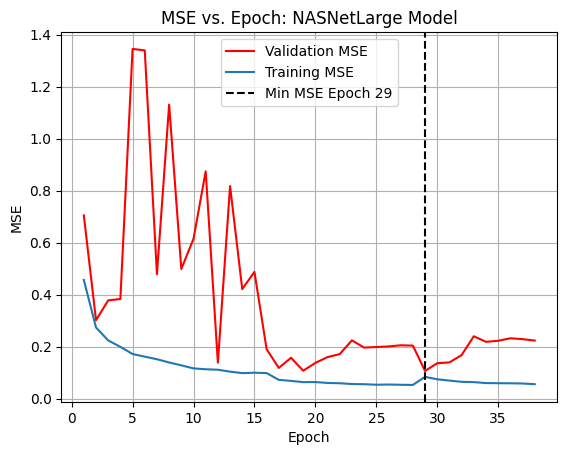

In [25]:
NASNetLargehistory = {}
for key in NASNetLargehistory_1.history:
    NASNetLargehistory[key] = NASNetLargehistory_1.history[key] + NASNetLargehistory_2.history[key]

def plot_mse(history):
    train_mse = history['mse']  
    test_mse = history['val_mse']  
    epochs = list(range(1, len(test_mse) + 1)) 

    min_mse_epoch = epochs[test_mse.index(min(test_mse))]  
    min_val_mse = min(test_mse)  

    plt.plot(epochs, test_mse, color='red', label='Validation MSE')
    plt.plot(epochs, train_mse, label='Training MSE')
    
    plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min MSE Epoch {min_mse_epoch}')
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    #plt.ylim(0,0.6)
    plt.title('MSE vs. Epoch: NASNetLarge Model')

    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse(NASNetLargehistory)


In [26]:
import pickle

# Save the combined history dictionary
with open('NASNetLarge_992025_history.pkl', 'wb') as f:
    pickle.dump(NASNetLargehistory, f)

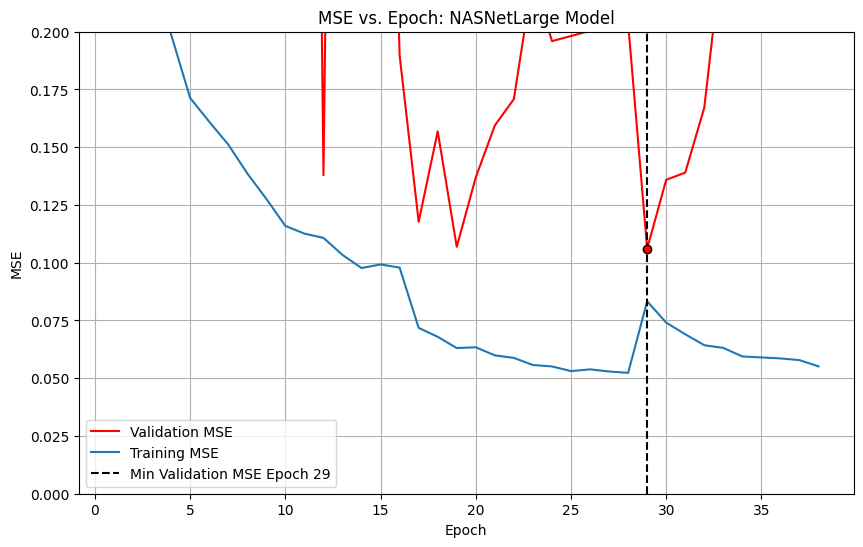

In [29]:
import matplotlib.pyplot as plt

NASNetLargehistory = {}
for key in NASNetLargehistory_1.history:
    NASNetLargehistory[key] = NASNetLargehistory_1.history[key] + NASNetLargehistory_2.history[key]

def plot_mse(history, save_path=None):
    train_mse = history['mse']  
    test_mse = history['val_mse']  
    epochs = list(range(1, len(test_mse) + 1)) 

    min_mse_epoch = epochs[test_mse.index(min(test_mse))]  
    min_val_mse = min(test_mse)  

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, test_mse, color='red', label='Validation MSE')
    plt.plot(epochs, train_mse, label='Training MSE')
    
    plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min Validation MSE Epoch {min_mse_epoch}')
    plt.scatter(min_mse_epoch, min_val_mse, color='red', edgecolor='black', zorder=5)    
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.ylim(0, 0.2)
    plt.title('MSE vs. Epoch: NASNetLarge Model')
    plt.legend()
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=700)
    plt.show()

#plot_mse(NASNetLargehistory, save_path='NASNetLargehistory.png')


In [28]:
#duration in secs for the process to finish
end = time.time()
end - start

19124.416427850723